In [14]:
!pip install timm torchvision torch --upgrade -q
!pip install scikit-learn matplotlib seaborn -q

In [15]:
import torch
import torchvision
import torch.nn as nn
import timm
import os
import json
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter
import requests
import time
import traceback
import math
from datetime import datetime, timedelta
from tqdm.notebook import tqdm
import copy
import csv                         
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                               accuracy_score, f1_score, roc_auc_score)
from torch.nn.functional import softmax


print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"timm        : {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Quick sanity check
model = timm.create_model('vit_base_patch16_224.augreg_in21k', pretrained=False, num_classes=4)
print(f"\nViT model loaded OK — params: {sum(p.numel() for p in model.parameters()):,}")

torch       : 2.12.0+cu130
torchvision : 0.27.0+cu130
timm        : 1.0.27
CUDA available: True
GPU: Tesla T4

ViT model loaded OK — params: 85,801,732


In [16]:
# OCT Dataset Setup

#CONFIG 
DATA_ROOT  = "/home/sagemaker-user/oct-dataset"
IMG_SIZE   = 224
BATCH_SIZE = 32
VAL_SPLIT  = 0.15    # 15% of train data used for validation
SEED       = 42

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train", "img")
TRAIN_ANN_DIR = os.path.join(DATA_ROOT, "train", "ann")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test",  "img")
TEST_ANN_DIR  = os.path.join(DATA_ROOT, "test",  "ann")


# JSON PARSER (Supervisely format) 
def get_label_from_ann(ann_path):
    with open(ann_path) as f:
        data = json.load(f)
    tags = data.get("tags", [])
    if not tags:
        return None     # unannotated image — will be skipped
    return tags[0]["name"]


#LOADS OCT IMAGES 
class OCTDataset(Dataset):
    def __init__(self, img_dir, ann_dir, class_to_idx, transform=None):
        self.img_dir      = img_dir
        self.ann_dir      = ann_dir
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.samples      = []   # list of (img_path, label_int)

        skipped = 0
        for ann_file in sorted(os.listdir(ann_dir)):
            if not ann_file.endswith(".json"):
                continue

            ann_path = os.path.join(ann_dir, ann_file)

            # Strip .json only — remainder is the full image filename
            # "CNV-1016042-1.jpeg.json" → "CNV-1016042-1.jpeg"
            img_filename = ann_file[:-5]
            img_path     = os.path.join(img_dir, img_filename)

            if not os.path.exists(img_path):
                skipped += 1
                continue

            label_name = get_label_from_ann(ann_path)
            if label_name is None or label_name not in self.class_to_idx:
                skipped += 1
                continue

            self.samples.append((img_path, self.class_to_idx[label_name]))

        if skipped > 0:
            print(f"  [INFO] Skipped {skipped} files (missing image or no annotation tag)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# AUTO-DISCOVER CLASS NAMES FROM TRAINING ANNOTATIONS 
print("Scanning annotations for class names...")
all_classes = set()
for ann_file in os.listdir(TRAIN_ANN_DIR):
    if ann_file.endswith(".json"):
        label = get_label_from_ann(os.path.join(TRAIN_ANN_DIR, ann_file))
        if label:
            all_classes.add(label)

class_to_idx = {cls: i for i, cls in enumerate(sorted(all_classes))}
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES  = len(class_to_idx)

print(f"Classes found : {class_to_idx}")
print(f"Num classes   : {NUM_CLASSES}")


# TRANSFORMS 
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# LOAD FULL TRAINING SET (no trasformation si done) 
print("\nLoading training annotations...")
full_train_ds = OCTDataset(TRAIN_IMG_DIR, TRAIN_ANN_DIR,
                           class_to_idx, transform=None)
print(f"Total training samples loaded: {len(full_train_ds)}")

all_labels = [lbl for _, lbl in full_train_ds.samples]


# STRATIFIED TRAIN / VAL SPLIT 
train_idx, val_idx = train_test_split(
    range(len(full_train_ds)),
    test_size    = VAL_SPLIT,
    stratify     = all_labels,   # preserves class balance in both splits 
    random_state = SEED,
)

print(f"\nTrain indices : {len(train_idx)}")
print(f"Val   indices : {len(val_idx)}")


# TRANSFORM-AWARE SUBSET WRAPPER 
# NOTE: Cannot use torch.utils.data.Subset here because both train and val
# would share the same transform from the base dataset.
# TransformSubset lets each split have its own transform independently.

class TransformSubset(Dataset):
    def __init__(self, indices, base_dataset, transform):
        self.indices   = list(indices)
        self.base      = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_path, label = self.base.samples[self.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = TransformSubset(train_idx, full_train_ds, train_transforms)
val_ds   = TransformSubset(val_idx,   full_train_ds, val_test_transforms)

print("\nLoading test annotations...")
test_ds  = OCTDataset(TEST_IMG_DIR, TEST_ANN_DIR,
                      class_to_idx, transform=val_test_transforms)
print(f"Test samples : {len(test_ds)}")


# DATALOADERS 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)


# SANITY CHECKS 
print("\nClass distribution")
train_labels = [full_train_ds.samples[i][1] for i in train_idx]
val_labels   = [full_train_ds.samples[i][1] for i in val_idx]
test_labels  = [lbl for _, lbl in test_ds.samples]

for split_name, label_list in [("Train", train_labels),
                                ("Val",   val_labels),
                                ("Test",  test_labels)]:
    counts = Counter(label_list)
    total  = len(label_list)
    print(f"\n  {split_name} ({total} samples):")
    for idx in sorted(counts):
        pct = counts[idx] / total * 100
        print(f"    {idx_to_class[idx]:12s}: {counts[idx]:>5}  ({pct:.1f}%)")

print("\nDataLoaders")
print(f"  Train  : {len(train_loader)} batches × batch_size {BATCH_SIZE}")
print(f"  Val    : {len(val_loader)} batches")
print(f"  Test   : {len(test_loader)} batches")

print("\nImage + label spot check")
for i in range(3):
    img_path, label_idx = full_train_ds.samples[i]
    print(f"  [{i}] {os.path.basename(img_path):40s} → {idx_to_class[label_idx]}")

print("\nDataset setup complete — ready for model training")


Scanning annotations for class names...
Classes found : {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
Num classes   : 4

Loading training annotations...
Total training samples loaded: 108309

Train indices : 92062
Val   indices : 16247

Loading test annotations...
Test samples : 1000

Class distribution

  Train (92062 samples):
    CNV         : 31624  (34.4%)
    DME         :  9646  (10.5%)
    DRUSEN      :  7323  (8.0%)
    NORMAL      : 43469  (47.2%)

  Val (16247 samples):
    CNV         :  5581  (34.4%)
    DME         :  1702  (10.5%)
    DRUSEN      :  1293  (8.0%)
    NORMAL      :  7671  (47.2%)

  Test (1000 samples):
    CNV         :   250  (25.0%)
    DME         :   250  (25.0%)
    DRUSEN      :   250  (25.0%)
    NORMAL      :   250  (25.0%)

DataLoaders
  Train  : 2877 batches × batch_size 32
  Val    : 508 batches
  Test   : 32 batches

Image + label spot check
  [0] CNV-1016042-1.jpeg                       → CNV
  [1] CNV-1016042-10.jpeg                      → 

In [17]:
# GPU check 
print ("GPU / Device Check")
print(f"  CUDA available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version     : {torch.version.cuda}")
    print(f"  Total VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"  Allocated now    : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    device = torch.device("cuda")
else:
    print("No GPU found")
    device = torch.device("cpu")

print(f"\n  Training device  : {device}")

GPU / Device Check
  CUDA available   : True
  GPU name         : Tesla T4
  CUDA version     : 13.0
  Total VRAM       : 15.6 GB
  Allocated now    : 1.14 GB

  Training device  : cuda


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k',
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)   # ← must be here

cnn_model = timm.create_model(
    'tf_efficientnetv2_s.in21k_ft_in1k',   # ← correct timm ID with pretrained weights
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)   # ← and here

print(f"ViT on: {next(vit_model.parameters()).device}")
print(f"CNN on: {next(cnn_model.parameters()).device}")

ViT on: cuda:0
CNN on: cuda:0


In [19]:
# Setting up Optimizers, Schedulers and  Loss Function
# CONFIG
EPOCHS        = 20
BASE_LR       = 1e-3      # head learning rate for ViT
LLRD_DECAY    = 0.85      # multiply LR by this for each deeper ViT block
WEIGHT_DECAY  = 0.05
CNN_LR        = 1e-4      # standard fine-tuning LR for CNN
LABEL_SMOOTH  = 0.1       # reduces overconfidence on noisy labels
WARMUP_EPOCHS = 3         # cosine schedule warm-up


# 1. LLRD OPTIMIZER FOR ViT
def get_llrd_optimizer(model, base_lr=1e-3, decay=0.85, weight_decay=0.05):
    param_groups = []

    # Head — highest LR
    head_params = list(model.head.parameters())
    param_groups.append({
        "params": head_params,
        "lr":     base_lr,
        "name":   "head"
    })

    # Transformer blocks — decay from top (block 11) to bottom (block 0)
    blocks = list(model.blocks.children())   # 12 blocks for ViT-B
    for i, block in enumerate(reversed(blocks)):
        lr = base_lr * (decay ** (i + 1))
        param_groups.append({
            "params": list(block.parameters()),
            "lr":     lr,
            "name":   f"block_{11 - i}"
        })

    # Everything else: patch embed, cls token, pos embed, norm
    block_param_ids = set(
        id(p) for p in model.head.parameters()
    ) | set(
        id(p) for block in model.blocks.children()
        for p in block.parameters()
    )
    other_params = [
        p for p in model.parameters()
        if id(p) not in block_param_ids
    ]
    param_groups.append({
        "params": other_params,
        "lr":     base_lr * (decay ** 13),
        "name":   "patch_embed_and_pos"
    })

    optimizer = torch.optim.AdamW(
        param_groups,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
    )
    return optimizer


vit_optimizer = get_llrd_optimizer(
    vit_model,
    base_lr      = BASE_LR,
    decay        = LLRD_DECAY,
    weight_decay = WEIGHT_DECAY,
)

# Print LR per layer group to verify decay
print("ViT LLRD Layer Groups")
for g in vit_optimizer.param_groups:
    n_params = sum(p.numel() for p in g["params"])
    print(f"  {g['name']:28s}  LR: {g['lr']:.2e}  Params: {n_params:>9,}")


# 2. STANDARD ADAMW FOR CNN
cnn_optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr           = CNN_LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.999),
)

print(f"\nCNN Optimizer")
print(f"  AdamW  LR: {CNN_LR:.2e}  Weight decay: {WEIGHT_DECAY}")


# 3. COSINE ANNEALING SCHEDULERS WITH LINEAR WARMUP
# Cosine decay brings LR smoothly to ~0 by epoch 20
# Linear warmup for first 3 epochs prevents instability at the start

def get_cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs          # linear warm-up
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        import math
        return 0.5 * (1.0 + math.cos(math.pi * progress))   # cosine decay

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


scheduler_vit = get_cosine_warmup_scheduler(vit_optimizer, WARMUP_EPOCHS, EPOCHS)
scheduler_cnn = get_cosine_warmup_scheduler(cnn_optimizer, WARMUP_EPOCHS, EPOCHS)

print(f"\nSchedulers")
print(f"  Cosine annealing with {WARMUP_EPOCHS}-epoch linear warmup")
print(f"  Total epochs: {EPOCHS}")


# 4. LOSS FUNCTION
# Label smoothing handles the class imbalance in the dataset:
# (CNV 34%, NORMAL 47%, DME 10.5%, DRUSEN 8%)
# It prevents the model becoming overconfident on NORMAL
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

print(f"\nLoss Function")
print(f"  CrossEntropyLoss  label_smoothing={LABEL_SMOOTH}")
print(f"\nOptimizers, schedulers, and loss ready")

ViT LLRD Layer Groups
  head                          LR: 1.00e-03  Params:     3,076
  block_11                      LR: 8.50e-04  Params: 7,087,872
  block_10                      LR: 7.22e-04  Params: 7,087,872
  block_9                       LR: 6.14e-04  Params: 7,087,872
  block_8                       LR: 5.22e-04  Params: 7,087,872
  block_7                       LR: 4.44e-04  Params: 7,087,872
  block_6                       LR: 3.77e-04  Params: 7,087,872
  block_5                       LR: 3.21e-04  Params: 7,087,872
  block_4                       LR: 2.72e-04  Params: 7,087,872
  block_3                       LR: 2.32e-04  Params: 7,087,872
  block_2                       LR: 1.97e-04  Params: 7,087,872
  block_1                       LR: 1.67e-04  Params: 7,087,872
  block_0                       LR: 1.42e-04  Params: 7,087,872
  patch_embed_and_pos           LR: 1.21e-04  Params:   744,192

CNN Optimizer
  AdamW  LR: 1.00e-04  Weight decay: 0.05

Schedulers
  Cosine anne

In [ ]:
# TELEGRAM CONFIG
TELEGRAM_TOKEN        = "#########"     # from BotFather (Step 1 below)
TELEGRAM_CHAT_ID      = "#######"       # from Cell 2 below
NOTIFY_EVERY_N_EPOCHS = 5
MODEL_NAME            = "ViT-B/16 OCT"

class TrainingNotifier:
    EMOJI = {
        "start": "", "epoch": "", "best": "",
        "warning": "", "error": "", "done": "",
        "early": "", "nan": "",
    }

    def __init__(self, token, chat_id, model_name="Model",
                 notify_every=5, silent_on_fail=True):
        self.token        = token
        self.chat_id      = str(chat_id)
        self.model_name   = model_name
        self.notify_every = notify_every
        self.silent       = silent_on_fail
        self.best_val_acc = 0.0
        self.train_start  = None
        self.last_epoch_t = None
        self._url         = f"https://api.telegram.org/bot{self.token}/sendMessage"

    def _send(self, text):
        try:
            r = requests.post(
                self._url,
                json={"chat_id": self.chat_id, "text": text, "parse_mode": "HTML"},
                timeout=10,
            )
            return r.status_code == 200
        except Exception as exc:
            if not self.silent:
                raise
            print(f"[Notifier] Telegram failed (non-fatal): {exc}")
            return False

    def _elapsed(self):
        if not self.train_start:
            return "—"
        return str(timedelta(seconds=int(time.time() - self.train_start)))

    def _eta(self, epoch, total):
        if not self.train_start or epoch == 0:
            return "—"
        elapsed = time.time() - self.train_start
        return str(timedelta(seconds=int(elapsed / epoch * (total - epoch))))

    def _fmt(self, epoch, total, tl, ta, vl, va, lr):
        return (
            f"Epoch: {epoch}/{total}\n"
            f"Train  — Loss: {tl:.4f}  Acc: {ta:.4f}\n"
            f"Val    — Loss: {vl:.4f}  Acc: {va:.4f}\n"
            f"Best Val Acc: {self.best_val_acc:.4f}\n"
            f"LR: {lr:.2e}\n"
            f"Elapsed: {self._elapsed()} | ETA: {self._eta(epoch, total)}\n"
            f"{datetime.now().strftime('%H:%M:%S')}"
        )

    def test_connection(self):
        ok = self._send(f"<b>Notifier ready — {self.model_name}</b>\nSageMaker connected.")
        print("Telegram OK" if ok else "FAILED — check TOKEN and CHAT_ID.")
        return ok

    def on_train_start(self, total_epochs, num_classes, dataset_size):
        self.train_start  = time.time()
        self.last_epoch_t = time.time()
        self._send(
            f"<b>{self.model_name} — Training started</b>\n"
            f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"
            f"Total epochs: {total_epochs}\n"
            f"Classes: {num_classes}\n"
            f"Training samples: {dataset_size:,}"
        )

    def on_epoch_end(self, epoch, total_epochs,
                     train_loss, train_acc, val_loss, val_acc, lr):
        epoch_dur = time.time() - (self.last_epoch_t or self.train_start)
        self.last_epoch_t = time.time()

        # NaN check
        if not math.isfinite(train_loss) or not math.isfinite(val_loss):
            self._send(
                f"<b>{self.model_name} — Non-finite loss!</b>\n"
                f"Epoch {epoch} | Train: {train_loss} | Val: {val_loss}\n"
                f"Check LR, gradient clipping, and normalisation."
            )
            raise ValueError(f"Non-finite loss at epoch {epoch}")

        # Best model
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self._send(
                f"<b>{self.model_name} — New best!</b>\n"
                + self._fmt(epoch, total_epochs, train_loss, train_acc, val_loss, val_acc, lr)
            )

        # Periodic update
        if epoch % self.notify_every == 0:
            self._send(
                f"<b>{self.model_name} — Epoch {epoch}/{total_epochs}</b>\n"
                + self._fmt(epoch, total_epochs, train_loss, train_acc, val_loss, val_acc, lr)
                + f"\nEpoch took: {str(timedelta(seconds=int(epoch_dur)))}"
            )

    def on_no_improvement(self, epoch, patience, waited):
        self._send(
            f"<b>{self.model_name} — Plateau warning</b>\n"
            f"Epoch {epoch} | No improvement for {waited}/{patience} epochs\n"
            f"Best Val Acc: {self.best_val_acc:.4f}"
        )

    def on_early_stop(self, epoch):
        self._send(
            f"<b>{self.model_name} — Early stopping at epoch {epoch}</b>\n"
            f"Best Val Acc: {self.best_val_acc:.4f} | Total time: {self._elapsed()}"
        )

    def on_error(self, epoch=None, exc=None):
        loc = f"epoch {epoch}" if epoch else "setup"
        tb  = traceback.format_exc()[-800:] if exc else "No traceback"
        self._send(
            f"<b>{self.model_name} — Training CRASHED</b>\n"
            f"Location: {loc} | Elapsed: {self._elapsed()}\n\n"
            f"<code>{tb}</code>"
        )

    def on_train_end(self, total_epochs):
        self._send(
            f"<b>{self.model_name} — Training complete!</b>\n"
            f"Epochs: {total_epochs} | Best Val Acc: <b>{self.best_val_acc:.4f}</b>\n"
            f"Total time: {self._elapsed()}\n"
            f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
        )


notifier = TrainingNotifier(
    token         = TELEGRAM_TOKEN,
    chat_id       = TELEGRAM_CHAT_ID,
    model_name    = MODEL_NAME,
    notify_every  = NOTIFY_EVERY_N_EPOCHS,
    silent_on_fail= True,
)

In [21]:
notifier.test_connection()

Telegram OK


True

In [ ]:
# (Experiment -1) Training Loop (ViT + CNN, with Telegram + per-epoch CSV logging)

PATIENCE = 5
SAVE_DIR = "/home/sagemaker-user/oct-dataset"
LOG_DIR  = "/home/sagemaker-user/oct-dataset/logs"  
os.makedirs(LOG_DIR, exist_ok=True)                    


# NEW: CSV logger — creates file on first call, appends on every epoch 
def log_epoch_to_csv(log_path, epoch, total_epochs, model_name,
                     train_loss, train_acc, val_loss, val_acc,
                     best_val_acc, lr, epoch_time_sec, is_best):
    file_exists = os.path.exists(log_path)

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)

        # Write header only on first epoch
        if not file_exists:
            writer.writerow([
                "timestamp", "model", "epoch", "total_epochs",
                "train_loss", "train_acc",
                "val_loss",   "val_acc",
                "best_val_acc", "lr",
                "epoch_time_sec", "epoch_time_min", "is_best"
            ])

        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            model_name,
            epoch,
            total_epochs,
            f"{train_loss:.6f}",
            f"{train_acc:.6f}",
            f"{val_loss:.6f}",
            f"{val_acc:.6f}",
            f"{best_val_acc:.6f}",
            f"{lr:.2e}",
            f"{epoch_time_sec:.1f}",
            f"{epoch_time_sec/60:.2f}",
            int(is_best),
        ])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix({
            "loss": f"{total_loss / (pbar.n + 1):.4f}",
            "acc":  f"{correct / total:.4f}"
        })
    return total_loss / len(loader), correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Val  ", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")
    with torch.no_grad():
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            out         = model(imgs)
            total_loss += criterion(out, labels).item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix({
                "loss": f"{total_loss / (pbar.n + 1):.4f}",
                "acc":  f"{correct / total:.4f}"
            })
    return total_loss / len(loader), correct / total


# GENERIC TRAINING FUNCTION 
def train_model(model, model_name, optimizer, scheduler,
                train_loader, val_loader, criterion,
                device, epochs, patience, save_path, notifier=None):

    best_val_acc = 0.0
    best_weights = None
    no_improve   = 0
    history      = {"train_loss": [], "train_acc": [],
                    "val_loss":   [], "val_acc":   []}

    # one CSV file per model 
    safe_name = model_name.replace("/", "-").replace(" ", "_")
    log_path  = os.path.join(LOG_DIR, f"{safe_name}_training_log.csv")
    print(f"  Epoch log → {log_path}")   # NEW

    if notifier:
        notifier.best_val_acc = 0.0
        notifier.model_name   = model_name
        notifier.train_start  = time.time()
        notifier.on_train_start(epochs, NUM_CLASSES, len(train_loader.dataset))

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Epochs: {epochs}  |  Patience: {patience}")
    print(f"{'='*60}")

    try:
        for epoch in range(1, epochs + 1):
            epoch_start = time.time()

            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device)
            val_loss, val_acc = eval_one_epoch(
                model, val_loader, criterion, device)
            scheduler.step()

            epoch_time = time.time() - epoch_start
            current_lr = optimizer.param_groups[0]["lr"]

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # checkpoint 
            is_best = val_acc > best_val_acc           
            if is_best:
                best_val_acc = val_acc
                best_weights = copy.deepcopy(model.state_dict())
                torch.save(best_weights, save_path)
                print(f"  New best saved → {save_path}  (val_acc={best_val_acc:.4f})")
                no_improve = 0
            else:
                no_improve += 1

            # this writes epochs to CSV immediately after it completes 
            log_epoch_to_csv(
                log_path      = log_path,
                epoch         = epoch,
                total_epochs  = epochs,
                model_name    = model_name,
                train_loss    = train_loss,
                train_acc     = train_acc,
                val_loss      = val_loss,
                val_acc       = val_acc,
                best_val_acc  = best_val_acc,
                lr            = current_lr,
                epoch_time_sec= epoch_time,
                is_best       = is_best,
            )

            # console log 
            eta = timedelta(seconds=int(epoch_time * (epochs - epoch)))
            print(
                f"  Ep {epoch:>3}/{epochs} | "
                f"T-Loss {train_loss:.4f}  T-Acc {train_acc:.4f} | "
                f"V-Loss {val_loss:.4f}  V-Acc {val_acc:.4f} | "
                f"Best {best_val_acc:.4f} | "
                f"LR {current_lr:.2e} | "
                f" {epoch_time/60:.1f}min  ETA {eta}"
            )

            # telegram 
            if notifier:
                notifier.on_epoch_end(
                    epoch=epoch, total_epochs=epochs,
                    train_loss=train_loss, train_acc=train_acc,
                    val_loss=val_loss, val_acc=val_acc,
                    lr=current_lr,
                )

            # early stopping 
            if no_improve == patience // 2 and notifier:
                notifier.on_no_improvement(epoch, patience, no_improve)

            if no_improve >= patience:
                print(f"\n  Early stopping at epoch {epoch} — no improvement for {patience} epochs")
                if notifier:
                    notifier.on_early_stop(epoch)
                break

    except Exception as e:
        if notifier:
            notifier.on_error(epoch=epoch, exc=e)
        raise

    if best_weights:
        model.load_state_dict(best_weights)
        print(f"\n  Best weights restored — val_acc: {best_val_acc:.4f}")

    if notifier:
        notifier.on_train_end(total_epochs=epoch)

    return history


# TRAINING ViT
vit_history = train_model(
    model        = vit_model,
    model_name   = "ViT-B/16 OCT",
    optimizer    = vit_optimizer,
    scheduler    = scheduler_vit,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = device,
    epochs       = EPOCHS,
    patience     = PATIENCE,
    save_path    = f"{SAVE_DIR}/vit_best.pth",
    notifier     = notifier,
)

# CNN
cnn_optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=CNN_LR, weight_decay=WEIGHT_DECAY
)
scheduler_cnn = get_cosine_warmup_scheduler(cnn_optimizer, WARMUP_EPOCHS, EPOCHS)

cnn_history = train_model(
    model        = cnn_model,
    model_name   = "CNN Baseline OCT",
    optimizer    = cnn_optimizer,
    scheduler    = scheduler_cnn,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = device,
    epochs       = EPOCHS,
    patience     = PATIENCE,
    save_path    = f"{SAVE_DIR}/cnn_best.pth",
    notifier     = notifier,
)

print("\n Both models trained — ready for Step 7: Evaluation")

  📄 Epoch log → /home/sagemaker-user/oct-dataset/logs/ViT-B-16_OCT_training_log.csv

  Training: ViT-B/16 OCT
  Epochs: 20  |  Patience: 5


  Train:   0%|                              | 0/2877 [00:00<?, ?it/s]

Loading saved checkpoints...
   ViT checkpoint loaded
   CNN checkpoint loaded

Running inference on test set...
  ViT predictions  : 1000 samples
  CNN predictions  : 1000 samples

  ViT-B/16 — Test Set Results
  Accuracy  : 0.9190  (91.90%)
  Macro F1  : 0.9154

  Per-class breakdown:
  Class         Precision     Recall         F1    Support
  ----------------------------------------------------
  CNV              0.8261     0.9880     0.8998        250
  DME              0.9579     1.0000     0.9785        250 
  DRUSEN           1.0000     0.7040     0.8263        250   LOW RECALL
  NORMAL           0.9318     0.9840     0.9572        250

   Note: DME and DRUSEN recall matters most for medical use

  CNN Baseline — Test Set Results
  Accuracy  : 0.9690  (96.90%)
  Macro F1  : 0.9689

  Per-class breakdown:
  Class         Precision     Recall         F1    Support
  ----------------------------------------------------
  CNV              0.9025     1.0000     0.9488        250
  D

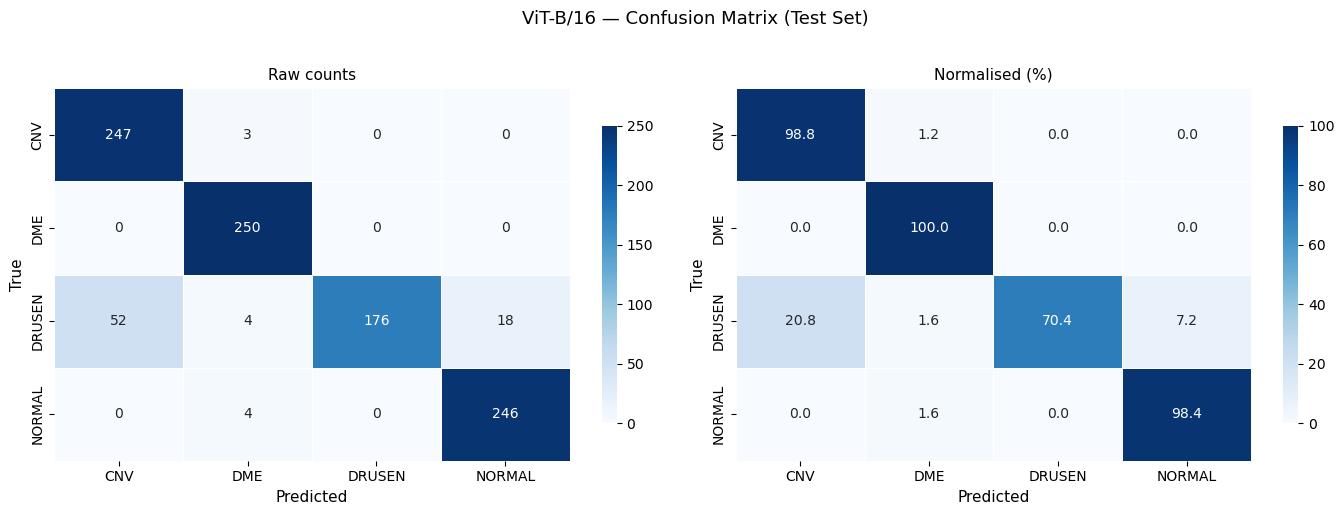

  Saved → /home/sagemaker-user/oct-dataset/Eval/vit_confusion_matrix.png


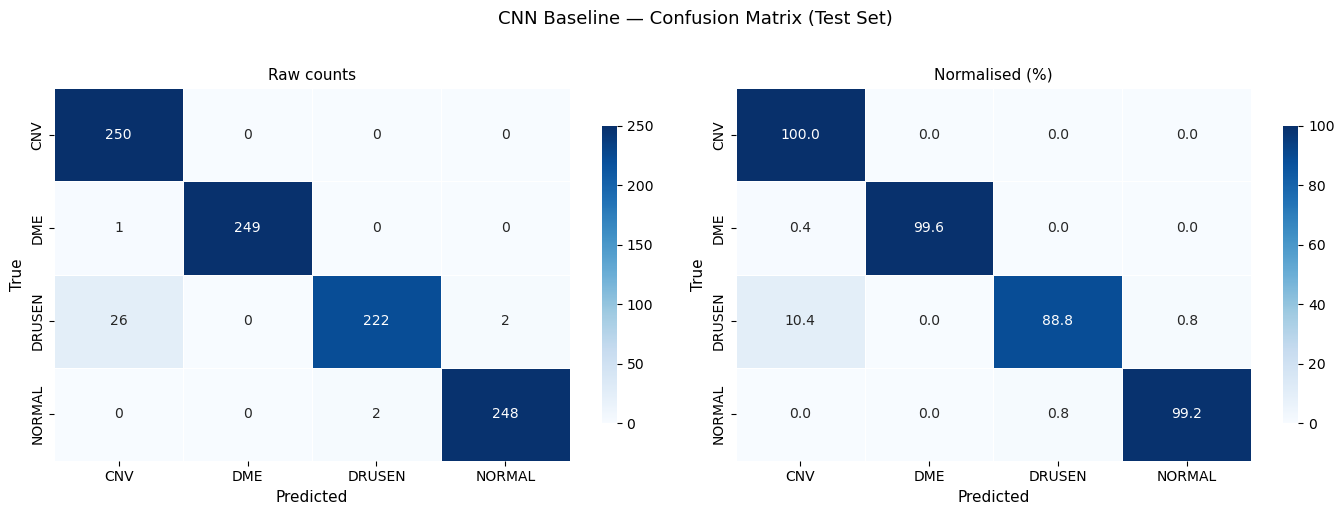

  Saved → /home/sagemaker-user/oct-dataset/Eval/cnn_confusion_matrix.png

 All evaluation files saved to: /home/sagemaker-user/oct-dataset/Eval
    - vit_classification_report.csv
    - cnn_classification_report.csv
    - vit_confusion_matrix.csv / .png
    - cnn_confusion_matrix.csv / .png
    - model_comparison.csv


In [22]:
#Full Evaluation: ViT + CNN on Test Set

EVAL_OUT_DIR = "/home/sagemaker-user/oct-dataset/Eval"
SAVE_DIR = "/home/sagemaker-user/oct-dataset"
os.makedirs(EVAL_OUT_DIR, exist_ok=True)

CLASS_NAMES = [idx_to_class[i] for i in range(NUM_CLASSES)]


# run inference on test set 
def get_predictions(model, loader, device):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            preds  = model(imgs).argmax(dim=1)
            all_true.extend(labels.numpy())
            all_pred.extend(preds.cpu().numpy())
    return np.array(all_true), np.array(all_pred)


# print a clean metric summary 
def print_metrics(model_name, y_true, y_pred):
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{'='*60}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Macro F1  : {macro_f1:.4f}")
    print(f"\n  Per-class breakdown:")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*52}")

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    for cls in CLASS_NAMES:
        r = report[cls]
        flag = ""
        if cls in ["DME", "DRUSEN"] and r["recall"] < 0.85:
            flag = "   LOW RECALL"
        elif cls in ["DME", "DRUSEN"] and r["recall"] >= 0.90:
            flag = " "
        print(
            f"  {cls:<12} {r['precision']:>10.4f} {r['recall']:>10.4f} "
            f"{r['f1-score']:>10.4f} {int(r['support']):>10}{flag}"
        )
    print(f"\n   Note: DME and DRUSEN recall matters most for medical use")
    return acc, macro_f1, report


# plot confusion matrix 
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm  = confusion_matrix(y_true, y_pred)
    # normalised (% of true class)
    cmn = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Confusion Matrix (Test Set)", fontsize=13, y=1.02)

    for ax, data, fmt, title in zip(
        axes,
        [cm,  cmn],
        ["d", ".1f"],
        ["Raw counts", "Normalised (%)"]
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}
        )
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.set_title(title,        fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")
    return cm


# 1. LOAD SAVED CHECKPOINTS
print("Loading saved checkpoints...")

vit_model.load_state_dict(
    torch.load(f"{SAVE_DIR}/vit_best.pth", map_location=device)
)
print("   ViT checkpoint loaded")

cnn_model.load_state_dict(
    torch.load(f"{SAVE_DIR}/cnn_best.pth", map_location=device)
)
print("   CNN checkpoint loaded")


# 2. GET PREDICTIONS
print("\nRunning inference on test set...")

vit_true, vit_pred = get_predictions(vit_model, test_loader, device)
cnn_true, cnn_pred = get_predictions(cnn_model, test_loader, device)

print(f"  ViT predictions  : {len(vit_pred)} samples")
print(f"  CNN predictions  : {len(cnn_pred)} samples")


# 3. PRINT METRICS
vit_acc, vit_f1, vit_report = print_metrics("ViT-B/16", vit_true, vit_pred)
cnn_acc, cnn_f1, cnn_report = print_metrics("CNN Baseline", cnn_true, cnn_pred)


# 4. SIDE-BY-SIDE COMPARISON TABLE
print(f"\n{'='*60}")
print(f"  Model Comparison")
print(f"{'='*60}")
print(f"  {'Metric':<25} {'ViT-B/16':>12} {'CNN':>12} {'Winner':>10}")
print(f"  {'-'*60}")

metrics = [
    ("Test Accuracy",    vit_acc,                           cnn_acc),
    ("Macro F1",         vit_f1,                            cnn_f1),
    ("CNV Recall",       vit_report["CNV"]["recall"],       cnn_report["CNV"]["recall"]),
    ("DME Recall",       vit_report["DME"]["recall"],       cnn_report["DME"]["recall"]),
    ("DRUSEN Recall",    vit_report["DRUSEN"]["recall"],    cnn_report["DRUSEN"]["recall"]),
    ("NORMAL Recall",    vit_report["NORMAL"]["recall"],    cnn_report["NORMAL"]["recall"]),
]

for name, vit_val, cnn_val in metrics:
    winner = "ViT" if vit_val >= cnn_val else "CNN"
    print(f"  {name:<25} {vit_val:>12.4f} {cnn_val:>12.4f} {winner:>10}")


# 5. CONFUSION MATRICES
vit_cm = plot_confusion_matrix(
    vit_true, vit_pred,
    model_name = "ViT-B/16",
    save_path  = f"{EVAL_OUT_DIR}/vit_confusion_matrix.png"
)

cnn_cm = plot_confusion_matrix(
    cnn_true, cnn_pred,
    model_name = "CNN Baseline",
    save_path  = f"{EVAL_OUT_DIR}/cnn_confusion_matrix.png"
)


# 6. SAVE EVERYTHING TO CSV
for model_name, report, cm, prefix in [
    ("ViT-B/16",     vit_report, vit_cm, "vit"),
    ("CNN Baseline", cnn_report, cnn_cm, "cnn"),
]:
    pd.DataFrame(report).transpose().to_csv(
        f"{EVAL_OUT_DIR}/{prefix}_classification_report.csv"
    )
    pd.DataFrame(
        cm,
        index   = CLASS_NAMES,
        columns = CLASS_NAMES
    ).to_csv(f"{EVAL_OUT_DIR}/{prefix}_confusion_matrix.csv")

# Summary CSV 
summary = pd.DataFrame([
    {
        "Model":         m,
        "Test Accuracy": acc,
        "Macro F1":      f1,
        "CNV Recall":    rep["CNV"]["recall"],
        "DME Recall":    rep["DME"]["recall"],
        "DRUSEN Recall": rep["DRUSEN"]["recall"],
        "NORMAL Recall": rep["NORMAL"]["recall"],
    }
    for m, acc, f1, rep in [
        ("ViT-B/16",     vit_acc, vit_f1, vit_report),
        ("CNN Baseline", cnn_acc, cnn_f1, cnn_report),
    ]
])
summary.to_csv(f"{EVAL_OUT_DIR}/model_comparison.csv", index=False)

print(f"\n All evaluation files saved to: {EVAL_OUT_DIR}")
print(f"    - vit_classification_report.csv")
print(f"    - cnn_classification_report.csv")
print(f"    - vit_confusion_matrix.csv / .png")
print(f"    - cnn_confusion_matrix.csv / .png")
print(f"    - model_comparison.csv")

In [23]:
# (Experiment - 2) — Load DeiT3 + ConvNeXt (Hybrid CNN+ViT) Models

# DeiT3
deit_model = timm.create_model(
    'deit3_base_patch16_224.fb_in22k_ft_in1k',
    pretrained  = True,
    num_classes = NUM_CLASSES
).to(device)

#ConvNeXt
convnext_model = timm.create_model(
    'convnext_base.fb_in22k_ft_in1k',
    pretrained  = True,
    num_classes = NUM_CLASSES
).to(device)

print(f"DeiT3    on : {next(deit_model.parameters()).device}")
print(f"ConvNeXt on : {next(convnext_model.parameters()).device}")
print(f"DeiT3    params : {sum(p.numel() for p in deit_model.parameters()):,}")
print(f"ConvNeXt params : {sum(p.numel() for p in convnext_model.parameters()):,}")

DeiT3    on : cuda:0
ConvNeXt on : cuda:0
DeiT3    params : 85,819,396
ConvNeXt params : 87,570,564


In [24]:
#Optimizers and Schedulers for DeiT3 and ConvNeXt

# DeiT3 — same LLRD setup as ViT since it  is also a transformer 
deit_optimizer = get_llrd_optimizer(
    deit_model,
    base_lr      = 1e-3,
    decay        = 0.90,    # slightly less aggressive than ViT — DeiT is more robust
    weight_decay = 0.05,
)

scheduler_deit = get_cosine_warmup_scheduler(deit_optimizer, WARMUP_EPOCHS, EPOCHS)

# Print LLRD groups for DeiT
print(" DeiT3 LLRD Layer Groups ")
for g in deit_optimizer.param_groups:
    n = sum(p.numel() for p in g["params"])
    print(f"  {g['name']:28s}  LR: {g['lr']:.2e}  Params: {n:>9,}")

# ConvNeXt — flat AdamW No llrd because it is not a transformer
convnext_optimizer = torch.optim.AdamW(
    convnext_model.parameters(),
    lr           = 1e-4,
    weight_decay = 0.05,
    betas        = (0.9, 0.999),
)

scheduler_convnext = get_cosine_warmup_scheduler(convnext_optimizer, WARMUP_EPOCHS, EPOCHS)

print(f"\n ConvNeXt Optimizer ")
print(f"  AdamW  LR: 1e-4  Weight decay: 0.05")

 DeiT3 LLRD Layer Groups 
  head                          LR: 0.00e+00  Params:     3,076
  block_11                      LR: 0.00e+00  Params: 7,089,408
  block_10                      LR: 0.00e+00  Params: 7,089,408
  block_9                       LR: 0.00e+00  Params: 7,089,408
  block_8                       LR: 0.00e+00  Params: 7,089,408
  block_7                       LR: 0.00e+00  Params: 7,089,408
  block_6                       LR: 0.00e+00  Params: 7,089,408
  block_5                       LR: 0.00e+00  Params: 7,089,408
  block_4                       LR: 0.00e+00  Params: 7,089,408
  block_3                       LR: 0.00e+00  Params: 7,089,408
  block_2                       LR: 0.00e+00  Params: 7,089,408
  block_1                       LR: 0.00e+00  Params: 7,089,408
  block_0                       LR: 0.00e+00  Params: 7,089,408
  patch_embed_and_pos           LR: 0.00e+00  Params:   743,424

 ConvNeXt Optimizer 
  AdamW  LR: 1e-4  Weight decay: 0.05


In [25]:
#There are only functions only in this cell
SAVE_DIR = "/home/sagemaker-user/oct-dataset"
LOG_DIR  = "/home/sagemaker-user/oct-dataset/logs"
os.makedirs(LOG_DIR, exist_ok=True)


def log_epoch_to_csv(log_path, epoch, total_epochs, model_name,
                     train_loss, train_acc, val_loss, val_acc,
                     best_val_acc, lr, epoch_time_sec, is_best):
    file_exists = os.path.exists(log_path)
    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow([
                "timestamp", "model", "epoch", "total_epochs",
                "train_loss", "train_acc", "val_loss", "val_acc",
                "best_val_acc", "lr", "epoch_time_sec", "epoch_time_min", "is_best"
            ])
        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            model_name, epoch, total_epochs,
            f"{train_loss:.6f}", f"{train_acc:.6f}",
            f"{val_loss:.6f}",  f"{val_acc:.6f}",
            f"{best_val_acc:.6f}", f"{lr:.2e}",
            f"{epoch_time_sec:.1f}", f"{epoch_time_sec/60:.2f}", int(is_best),
        ])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix({
            "loss": f"{total_loss / (pbar.n + 1):.4f}",
            "acc":  f"{correct / total:.4f}"
        })
    return total_loss / len(loader), correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Val  ", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")
    with torch.no_grad():
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            out         = model(imgs)
            total_loss += criterion(out, labels).item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix({
                "loss": f"{total_loss / (pbar.n + 1):.4f}",
                "acc":  f"{correct / total:.4f}"
            })
    return total_loss / len(loader), correct / total


def train_model(model, model_name, optimizer, scheduler,
                train_loader, val_loader, criterion,
                device, epochs, patience, save_path, notifier=None):

    best_val_acc = 0.0
    best_weights = None
    no_improve   = 0
    history      = {"train_loss": [], "train_acc": [],
                    "val_loss":   [], "val_acc":   []}

    safe_name = model_name.replace("/", "-").replace(" ", "_")
    log_path  = os.path.join(LOG_DIR, f"{safe_name}_training_log.csv")
    print(f"  Epoch log → {log_path}")

    if notifier:
        notifier.best_val_acc = 0.0
        notifier.model_name   = model_name
        notifier.train_start  = time.time()
        notifier.on_train_start(epochs, NUM_CLASSES, len(train_loader.dataset))

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Epochs: {epochs}  |  Patience: {patience}")
    print(f"{'='*60}")

    try:
        for epoch in range(1, epochs + 1):
            epoch_start = time.time()

            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device)
            val_loss, val_acc = eval_one_epoch(
                model, val_loader, criterion, device)
            scheduler.step()

            epoch_time = time.time() - epoch_start
            current_lr = optimizer.param_groups[0]["lr"]

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            is_best = val_acc > best_val_acc
            if is_best:
                best_val_acc = val_acc
                best_weights = copy.deepcopy(model.state_dict())
                torch.save(best_weights, save_path)
                print(f"  New best saved → {save_path}  (val_acc={best_val_acc:.4f})")
                no_improve = 0
            else:
                no_improve += 1

            log_epoch_to_csv(
                log_path=log_path, epoch=epoch, total_epochs=epochs,
                model_name=model_name, train_loss=train_loss, train_acc=train_acc,
                val_loss=val_loss, val_acc=val_acc, best_val_acc=best_val_acc,
                lr=current_lr, epoch_time_sec=epoch_time, is_best=is_best,
            )

            eta = timedelta(seconds=int(epoch_time * (epochs - epoch)))
            print(
                f"  Ep {epoch:>3}/{epochs} | "
                f"T-Loss {train_loss:.4f}  T-Acc {train_acc:.4f} | "
                f"V-Loss {val_loss:.4f}  V-Acc {val_acc:.4f} | "
                f"Best {best_val_acc:.4f} | "
                f"LR {current_lr:.2e} | "
                f" {epoch_time/60:.1f}min  ETA {eta}"
            )

            if notifier:
                notifier.on_epoch_end(
                    epoch=epoch, total_epochs=epochs,
                    train_loss=train_loss, train_acc=train_acc,
                    val_loss=val_loss, val_acc=val_acc,
                    lr=current_lr,
                )

            if no_improve == patience // 2 and notifier:
                notifier.on_no_improvement(epoch, patience, no_improve)

            if no_improve >= patience:
                print(f"\n  Early stopping at epoch {epoch} — no improvement for {patience} epochs")
                if notifier:
                    notifier.on_early_stop(epoch)
                break

    except Exception as e:
        if notifier:
            notifier.on_error(epoch=epoch, exc=e)
        raise

    if best_weights:
        model.load_state_dict(best_weights)
        print(f"\n  Best weights restored — val_acc: {best_val_acc:.4f}")

    if notifier:
        notifier.on_train_end(total_epochs=epoch)

    return history


print("All functions defined — ready to train DeiT and ConvNeXt")

All functions defined — ready to train DeiT and ConvNeXt


In [26]:
EPOCHS       = 20
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 3

deit_optimizer = get_llrd_optimizer(deit_model, base_lr=1e-3, decay=0.90, weight_decay=WEIGHT_DECAY)
scheduler_deit = get_cosine_warmup_scheduler(deit_optimizer, WARMUP_EPOCHS, EPOCHS)

convnext_optimizer = torch.optim.AdamW(
    convnext_model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY
)
scheduler_convnext = get_cosine_warmup_scheduler(convnext_optimizer, WARMUP_EPOCHS, EPOCHS)

print("Optimizers and schedulers ready")

Optimizers and schedulers ready


In [ ]:
deit_history = train_model(
    model        = deit_model,
    model_name   = "DeiT3-B OCT",
    optimizer    = deit_optimizer,
    scheduler    = scheduler_deit,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = device,
    epochs       = EPOCHS,
    patience     = 10,
    save_path    = f"{SAVE_DIR}/deit_best.pth",
    notifier     = notifier,
)

  📄 Epoch log → /home/sagemaker-user/oct-dataset/logs/DeiT3-B_OCT_training_log.csv

  Training: DeiT3-B OCT
  Epochs: 20  |  Patience: 10


  Train:   0%|                              | 0/2877 [00:00<?, ?it/s]

In [ ]:
convnext_history = train_model(
    model        = convnext_model,
    model_name   = "ConvNeXt OCT",
    optimizer    = convnext_optimizer,
    scheduler    = scheduler_convnext,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    device       = device,
    epochs       = EPOCHS,
    patience     = 7,
    save_path    = f"{SAVE_DIR}/convnext_best.pth",
    notifier     = notifier,
)

In [28]:
# Uses saved .pth checkpoints + CSV log files


DATA_ROOT    = "/home/sagemaker-user/oct-dataset"
SAVE_DIR     = "/home/sagemaker-user/oct-dataset"
LOG_DIR      = "/home/sagemaker-user/oct-dataset/logs"
EVAL_OUT_DIR = "/home/sagemaker-user/oct-dataset/eval"
IMG_SIZE     = 224
BATCH_SIZE   = 32
VAL_SPLIT    = 0.15
SEED         = 42

os.makedirs(EVAL_OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# CLASS NAMES 
class_to_idx = {"CNV": 0, "DME": 1, "DRUSEN": 2, "NORMAL": 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}
CLASS_NAMES  = ["CNV", "DME", "DRUSEN", "NORMAL"]
NUM_CLASSES  = 4


# DATASET + DATALOADER 
def get_label_from_ann(ann_path):
    with open(ann_path) as f:
        data = json.load(f)
    tags = data.get("tags", [])
    return tags[0]["name"] if tags else None

class OCTDataset(Dataset):
    def __init__(self, img_dir, ann_dir, class_to_idx, transform=None):
        self.transform    = transform
        self.class_to_idx = class_to_idx
        self.samples      = []
        for ann_file in sorted(os.listdir(ann_dir)):
            if not ann_file.endswith(".json"):
                continue
            ann_path     = os.path.join(ann_dir, ann_file)
            img_filename = ann_file[:-5]
            img_path     = os.path.join(img_dir, img_filename)
            if not os.path.exists(img_path):
                continue
            label = get_label_from_ann(ann_path)
            if label is None or label not in self.class_to_idx:
                continue
            self.samples.append((img_path, self.class_to_idx[label]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

class TransformSubset(Dataset):
    def __init__(self, indices, base_dataset, transform):
        self.indices   = list(indices)
        self.base      = base_dataset
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img_path, label = self.base.samples[self.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

val_test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

#  test loader 
test_ds = OCTDataset(
    os.path.join(DATA_ROOT, "test", "img"),
    os.path.join(DATA_ROOT, "test", "ann"),
    class_to_idx, transform=val_test_tf
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

print(f"Test samples : {len(test_ds)}")
print(f"Test batches : {len(test_loader)}")


# LOAD ALL 4 MODELS 
# Map: checkpoint filename to timm model name
checkpoint_map = {
    "ViT-B/16":     ("vit_base_patch16_224.augreg_in21k",        f"{SAVE_DIR}/vit_best.pth"),
    "CNN Baseline": ("tf_efficientnetv2_s.in21k_ft_in1k",        f"{SAVE_DIR}/cnn_best.pth"),  # confirmed 81.6 MB
    "DeiT3-B":      ("deit3_base_patch16_224.fb_in22k_ft_in1k",  f"{SAVE_DIR}/deit_best.pth"),
    "ConvNeXt":     ("convnext_base.fb_in22k_ft_in1k",           f"{SAVE_DIR}/convnext_best.pth"),
}

models_to_eval = []
for label, (timm_name, ckpt_path) in checkpoint_map.items():
    if os.path.exists(ckpt_path):
        m = timm.create_model(timm_name, pretrained=False,
                              num_classes=NUM_CLASSES).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        models_to_eval.append((m, label))
        print(f"  {label:<16} loaded")
    else:
        print(f"   {label:<16} checkpoint not found — skipping ({ckpt_path})")

print(f"\n {len(models_to_eval)} models ready for evaluation")


# SHOW LOG FILES 
print(f"\n Log files found in {LOG_DIR} ")
for f in sorted(os.listdir(LOG_DIR)):
    if f.endswith(".csv"):
        df   = pd.read_csv(os.path.join(LOG_DIR, f))
        rows = len(df)
        best = df["val_acc"].max()
        print(f"  {f}")
        print(f"     Epochs logged: {rows}  |  Best val acc: {best:.4f}")

Device: cuda
Test samples : 1000
Test batches : 32
  ViT-B/16         loaded
  CNN Baseline     loaded
  DeiT3-B          loaded
  ConvNeXt         loaded

 4 models ready for evaluation

 Log files found in /home/sagemaker-user/oct-dataset/logs 
  CNN_Baseline_OCT_training_log.csv
     Epochs logged: 20  |  Best val acc: 0.9842
  ConvNeXt_OCT_training_log.csv
     Epochs logged: 20  |  Best val acc: 0.9842
  DeiT3-B_OCT_training_log.csv
     Epochs logged: 12  |  Best val acc: 0.9595
  ViT-B-16_OCT_training_log.csv
     Epochs logged: 7  |  Best val acc: 0.9426


In [32]:
# EVALUATION CELL 1 

from torch.nn.functional import softmax

def get_predictions(model, loader, device):
    model.eval()
    all_true, all_pred, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            logits = model(imgs)
            probs  = softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(labels.numpy())
            all_pred.extend(preds)
            all_probs.extend(probs)
    return np.array(all_true), np.array(all_pred), np.array(all_probs)


all_results = {}

for model, name in models_to_eval:
    print(f"  Running inference: {name}...")
    y_true, y_pred, y_probs = get_predictions(model, test_loader, device)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report   = classification_report(
        y_true, y_pred,
        target_names = CLASS_NAMES,
        output_dict  = True
    )
    cm = confusion_matrix(y_true, y_pred)

    try:
        auc = roc_auc_score(
            pd.get_dummies(y_true).values,
            y_probs, multi_class="ovr", average="macro"
        )
    except Exception:
        auc = float("nan")

    all_results[name] = {
        "acc": acc, "f1": macro_f1, "auc": auc,
        "report": report, "cm": cm,
        "y_true": y_true, "y_pred": y_pred, "y_probs": y_probs
    }

    # Save classification report CSV
    safe = name.replace("/", "-").replace(" ", "_")
    pd.DataFrame(report).transpose().round(4).to_csv(
        f"{EVAL_OUT_DIR}/{safe}_classification_report.csv"
    )
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        f"{EVAL_OUT_DIR}/{safe}_confusion_matrix.csv"
    )

    print(f"    Accuracy: {acc*100:.2f}%  |  Macro F1: {macro_f1:.4f}  |  AUC: {auc:.4f}")

print("\n Inference complete — ready to plot")

  Running inference: ViT-B/16...
    Accuracy: 91.90%  |  Macro F1: 0.9154  |  AUC: 0.9969
  Running inference: CNN Baseline...
    Accuracy: 96.90%  |  Macro F1: 0.9689  |  AUC: 0.9936
  Running inference: DeiT3-B...
    Accuracy: 93.80%  |  Macro F1: 0.9372  |  AUC: 0.9958
  Running inference: ConvNeXt...
    Accuracy: 97.60%  |  Macro F1: 0.9760  |  AUC: 0.9983

 Inference complete — ready to plot


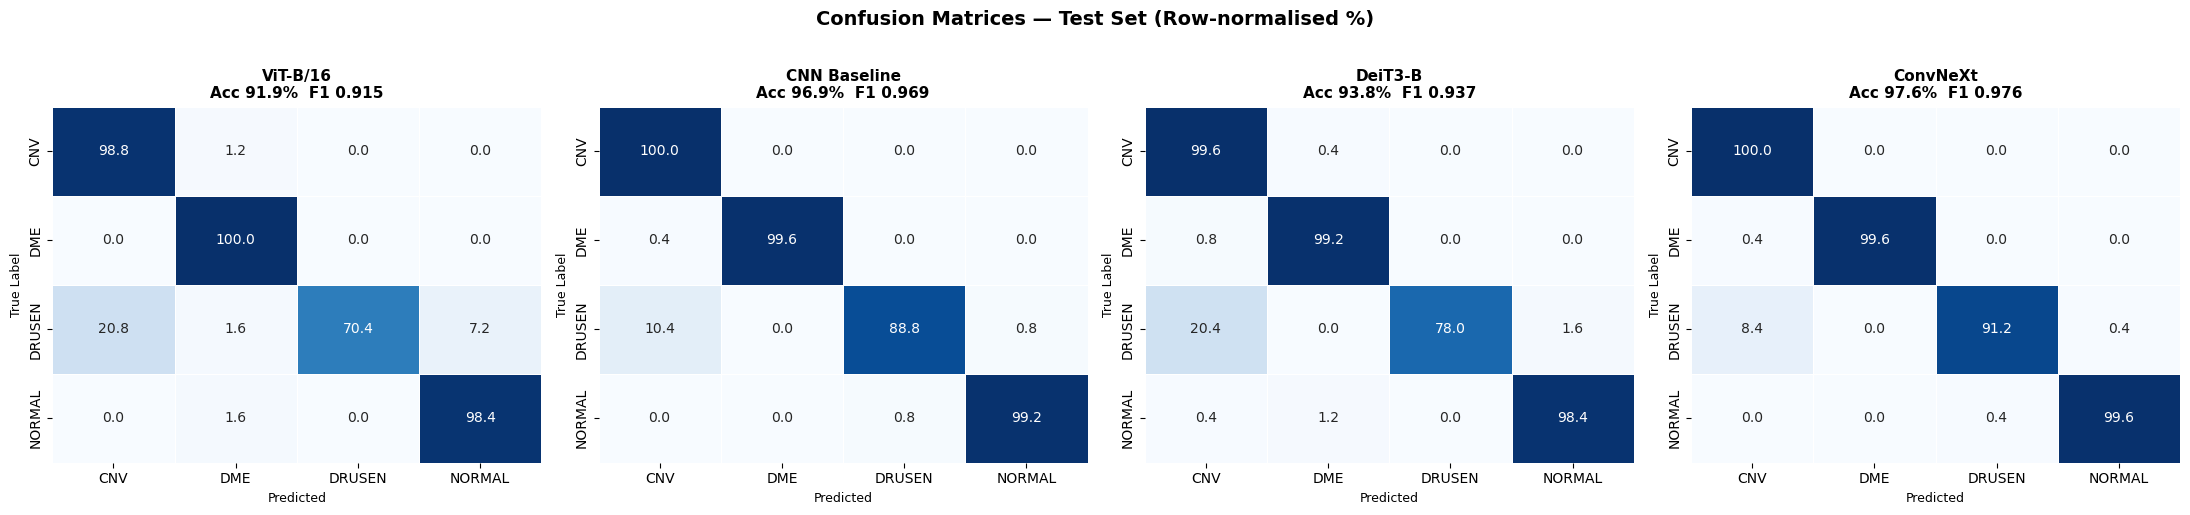

  Saved → chart1_confusion_matrices.png


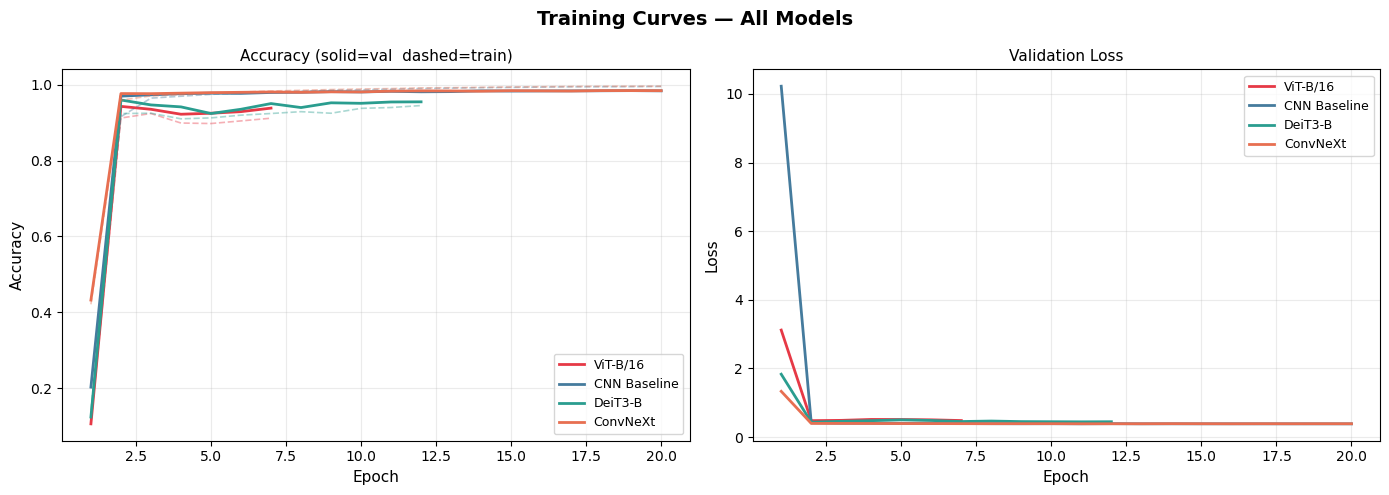

  Saved → chart2_training_curves.png


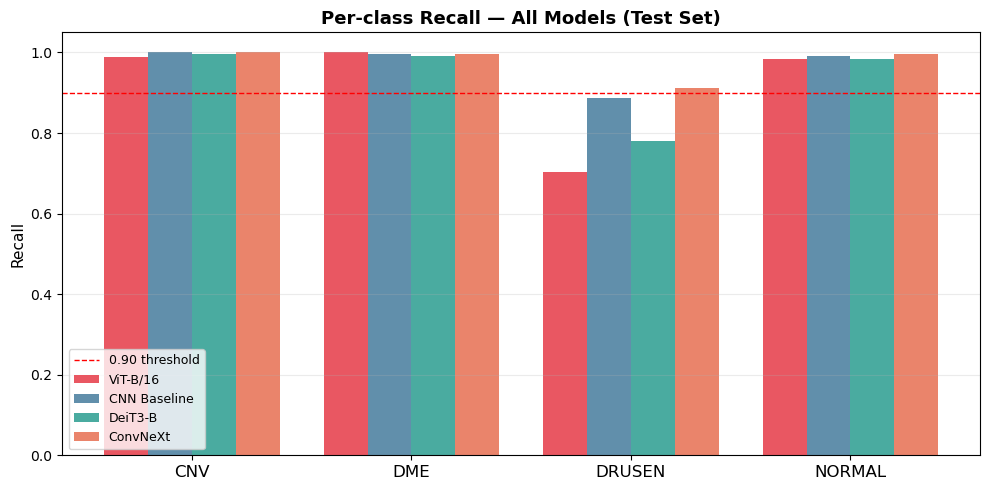

  Saved → chart3_per_class_recall.png


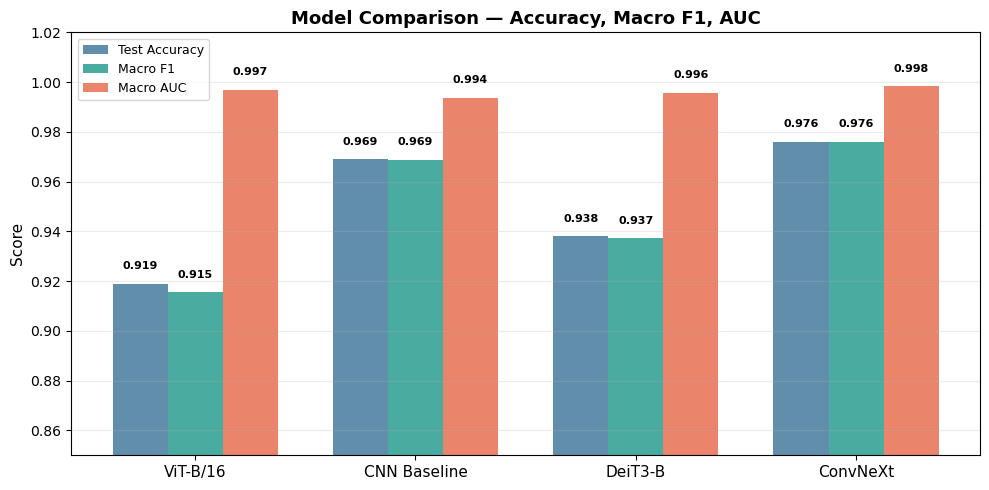

  Saved → chart4_model_comparison.png

  FINAL MODEL COMPARISON
  Model              Accuracy   Macro F1      AUC    DME-R    DRS-R   Best?
  ───────────────────────────────────────────────────────────────────────────
  ViT-B/16             0.9190     0.9154   0.9969   1.0000   0.7040        
  CNN Baseline         0.9690     0.9689   0.9936   0.9960   0.8880        
  DeiT3-B              0.9380     0.9372   0.9958   0.9920   0.7800        
  ConvNeXt             0.9760     0.9760   0.9983   0.9960   0.9120  WINNER

  Best model (Macro F1): ConvNeXt

 All files saved to: /home/sagemaker-user/oct-dataset/eval
   chart1_confusion_matrices.png
   chart2_training_curves.png
   chart3_per_class_recall.png
   chart4_model_comparison.png
   final_model_comparison.csv
   [model]_classification_report.csv  x 4
   [model]_confusion_matrix.csv       x 4


In [33]:
# EVALUATION CELL 2 

colors = {
    "ViT-B/16":     "#e63946",
    "CNN Baseline": "#457b9d",
    "DeiT3-B":      "#2a9d8f",
    "ConvNeXt":     "#e76f51",
}


# CHART 1: Confusion matrices (normalised %) 
n    = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5))
if n == 1: axes = [axes]
fig.suptitle("Confusion Matrices — Test Set (Row-normalised %)",
             fontsize=14, fontweight="bold", y=1.02)

for ax, (name, res) in zip(axes, all_results.items()):
    cm  = res["cm"]
    cmn = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cmn, annot=True, fmt=".1f", cmap="Blues", ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="white", cbar=False,
        annot_kws={"size": 10}
    )
    ax.set_title(
        f"{name}\nAcc {res['acc']*100:.1f}%  F1 {res['f1']:.3f}",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True Label", fontsize=9)

plt.tight_layout()
plt.savefig(f"{EVAL_OUT_DIR}/chart1_confusion_matrices.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("  Saved → chart1_confusion_matrices.png")


# CHART 2: Training curves from CSV logs 
log_name_map = {
    "ViT-B/16":     "ViT-B-16_OCT_training_log.csv",
    "CNN Baseline": "CNN_Baseline_OCT_training_log.csv",
    "DeiT3-B":      "DeiT3-B_OCT_training_log.csv",
    "ConvNeXt":     "ConvNeXt_OCT_training_log.csv",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")

any_logs = False
for name, fname in log_name_map.items():
    fpath = os.path.join(LOG_DIR, fname)
    if not os.path.exists(fpath):
        print(f"  [skip] log not found: {fname}")
        continue
    any_logs = True
    df = pd.read_csv(fpath)
    c  = colors.get(name, "gray")
    axes[0].plot(df["epoch"], df["train_acc"], color=c,
                 linestyle="--", alpha=0.4, linewidth=1.2)
    axes[0].plot(df["epoch"], df["val_acc"],   color=c,
                 linestyle="-",  linewidth=2, label=name)
    axes[1].plot(df["epoch"], df["val_loss"],  color=c,
                 linestyle="-",  linewidth=2, label=name)

if any_logs:
    for ax, title, ylabel in zip(
        axes,
        ["Accuracy (solid=val  dashed=train)", "Validation Loss"],
        ["Accuracy", "Loss"]
    ):
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(f"{EVAL_OUT_DIR}/chart2_training_curves.png",
                dpi=200, bbox_inches="tight")
    plt.show()
    print("  Saved → chart2_training_curves.png")


# CHART 3: Per-class recall bar chart 
recall_data = {
    name: [res["report"][cls]["recall"] for cls in CLASS_NAMES]
    for name, res in all_results.items()
}

recall_df = pd.DataFrame(recall_data, index=CLASS_NAMES)
x    = np.arange(len(CLASS_NAMES))
w    = 0.8 / len(all_results)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, vals) in enumerate(recall_data.items()):
    ax.bar(x + i * w, vals, width=w, label=name,
           color=colors.get(name, "gray"), alpha=0.85)

ax.axhline(0.90, color="red", linestyle="--", linewidth=1,
           label="0.90 threshold")
ax.set_xticks(x + w * (len(all_results) - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Per-class Recall — All Models (Test Set)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{EVAL_OUT_DIR}/chart3_per_class_recall.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("  Saved → chart3_per_class_recall.png")


# CHART 4: Overall metrics bar chart 
metric_names = ["Test Accuracy", "Macro F1", "Macro AUC"]
model_names  = list(all_results.keys())
metric_vals  = {
    "Test Accuracy": [all_results[m]["acc"]  for m in model_names],
    "Macro F1":      [all_results[m]["f1"]   for m in model_names],
    "Macro AUC":     [all_results[m]["auc"]  for m in model_names],
}

x  = np.arange(len(model_names))
w  = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ["#457b9d", "#2a9d8f", "#e76f51"]
for i, (metric, vals) in enumerate(metric_vals.items()):
    bars = ax.bar(x + i * w, vals, width=w,
                  label=metric, color=bar_colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

ax.set_xticks(x + w)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Accuracy, Macro F1, AUC",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{EVAL_OUT_DIR}/chart4_model_comparison.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("  Saved → chart4_model_comparison.png")


# FINAL COMPARISON TABLE 
print(f"\n{'='*75}")
print(f"  FINAL MODEL COMPARISON")
print(f"{'='*75}")
print(f"  {'Model':<16} {'Accuracy':>10} {'Macro F1':>10} {'AUC':>8} "
      f"{'DME-R':>8} {'DRS-R':>8} {'Best?':>7}")
print(f"  {'─'*75}")

summary_rows = []
best_f1 = max(r["f1"] for r in all_results.values())

for name, res in all_results.items():
    r    = res["report"]
    flag = "WINNER" if res["f1"] == best_f1 else ""
    print(
        f"  {name:<16} {res['acc']:>10.4f} {res['f1']:>10.4f} "
        f"{res['auc']:>8.4f} "
        f"{r['DME']['recall']:>8.4f} {r['DRUSEN']['recall']:>8.4f} "
        f"{flag:>7}"
    )
    summary_rows.append({
        "Model":         name,
        "Test Accuracy": round(res["acc"], 4),
        "Macro F1":      round(res["f1"],  4),
        "Macro AUC":     round(res["auc"], 4),
        "CNV Recall":    round(r["CNV"]["recall"],    4),
        "DME Recall":    round(r["DME"]["recall"],    4),
        "DRUSEN Recall": round(r["DRUSEN"]["recall"], 4),
        "NORMAL Recall": round(r["NORMAL"]["recall"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{EVAL_OUT_DIR}/final_model_comparison.csv", index=False)

best_model = summary_df.loc[summary_df["Macro F1"].idxmax(), "Model"]
print(f"\n  Best model (Macro F1): {best_model}")
print(f"\n All files saved to: {EVAL_OUT_DIR}")
print(f"   chart1_confusion_matrices.png")
print(f"   chart2_training_curves.png")
print(f"   chart3_per_class_recall.png")
print(f"   chart4_model_comparison.png")
print(f"   final_model_comparison.csv")
print(f"   [model]_classification_report.csv  x {len(all_results)}")
print(f"   [model]_confusion_matrix.csv       x {len(all_results)}")